# Decision Tree Algorithm

# 0/ Library Imports

In [1]:
"""
Library importation proecess for K-NN
This notebook is self-contained and initializes and installs the necessary libraries for the K-NN algorithm.
"""

# Numpy
%pip install pandas
import pandas as pd

# Sklearn
%pip install scikit-learn
# Import train_test_split function
from sklearn.model_selection import train_test_split
# Import DecisionTreeClassifier
from sklearn.tree import DecisionTreeClassifier
# Import Tree Visualization system
from sklearn.tree import plot_tree
# Import evaluation metrics
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, accuracy_score, confusion_matrix, f1_score, precision_score, recall_score, roc_curve, roc_auc_score, brier_score_loss
from sklearn.metrics import ConfusionMatrixDisplay
# Import GridSearchCV for hyperparameter tuning
from sklearn.model_selection import GridSearchCV

# Numpy
%pip install numpy
import numpy as np

# Matplotlib
%pip install matplotlib
import matplotlib.pyplot as plt

# Seaborn
%pip install seaborn
import seaborn as sns


[notice] A new release of pip is available: 24.3.1 -> 25.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.

[notice] A new release of pip is available: 24.3.1 -> 25.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.

[notice] A new release of pip is available: 24.3.1 -> 25.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.

[notice] A new release of pip is available: 24.3.1 -> 25.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.

[notice] A new release of pip is available: 24.3.1 -> 25.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


# 1/ Dataset Preparation

## 1.1/ Data Loading


In [2]:
"""
Dataset importation process for K-NN
Path to the dataset is '../datasets/all_dataset.csv'
"""

from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()

# Import [all_dataset.csv]
df = pd.read_csv('../datasets/all_dataset.csv')

df = df[df['timestamp'] != 0]
df = df[~df.isin([np.inf, -np.inf]).any(axis=1)]

df.fillna(df.median(), inplace=True)
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
numeric_cols.remove('winner')
df[numeric_cols] = scaler.fit_transform(df[numeric_cols])

df.fillna(df.median(), inplace=True)

# Show the first 15 rows of the dataset
df.head(15)

,timestamp,BLUE.HEXTECH_DRAGON.kills,BLUE.WATER_DRAGON.kills,BLUE.FIRE_DRAGON.kills,BLUE.EARTH_DRAGON.kills,BLUE.AIR_DRAGON.kills,BLUE.CHEMTECH_DRAGON.kills,BLUE.ELDER_DRAGON.kills,BLUE.RIFTHERALD.kills,BLUE.BARON_NASHOR.kills,...,soul_Mountain,soul_Ocean,BLUE.minionRatio,RED.minionRatio,BLUE.totalGoldRatio,RED.totalGoldRatio,BLUE.levelRatio,RED.levelRatio,BLUE.kda,RED.kda
1,0.000004,0.0,0.0,0.00,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.000000,0.000000,0.344908,0.333258,0.916031,0.915413,0.033613,0.027848
4,0.046862,0.0,0.0,0.00,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.516207,0.505364,0.101616,0.128358,0.662462,0.788548,0.009804,0.075949
5,0.062477,0.0,0.0,0.00,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.588619,0.569928,0.116130,0.112218,0.662505,0.763289,0.019608,0.037975
6,0.078092,0.0,0.0,0.00,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.593383,0.576440,0.117811,0.116459,0.620325,0.662087,0.022059,0.033755
7,0.093706,0.0,0.0,0.00,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.640869,0.636767,0.117568,0.115568,0.626379,0.589801,0.022059,0.033755
8,0.109323,0.0,0.0,0.00,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.637898,0.660685,0.111410,0.108119,0.567581,0.598834,0.022059,0.033755
9,0.124933,0.0,0.0,0.00,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.683096,0.676618,0.108545,0.113253,0.550038,0.549666,0.017647,0.042194
10,0.140549,0.0,0.0,0.00,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.719229,0.728312,0.115004,0.124769,0.586622,0.535606,0.014706,0.046414
11,0.156160,0.0,0.0,0.00,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.692703,0.715264,0.125650,0.123059,0.524476,0.478102,0.023109,0.032911
12,0.171778,0.0,0.0,0.25,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.676512,0.708429,0.125345,0.113336,0.514873,0.472342,0.027311,0.027426


## 1.2/ Handle missing values and infinities & Data Preprocessing

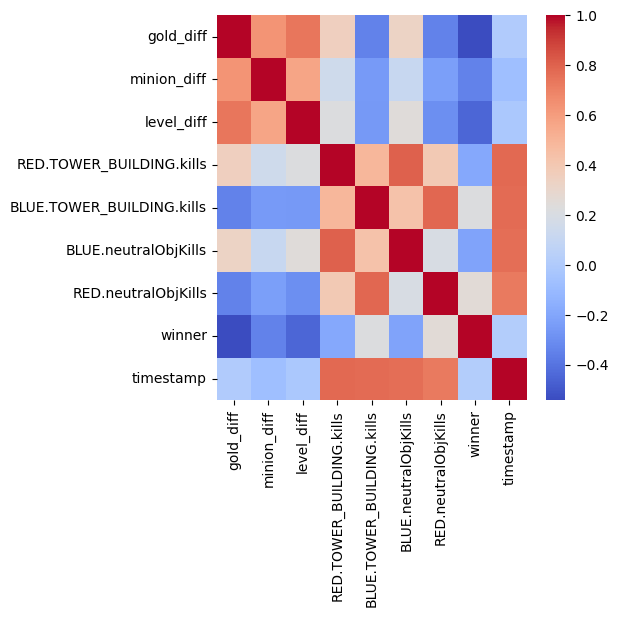

In [3]:
tdf = df.copy()
tdf = tdf.drop(columns=df.columns)
tdf['gold_diff'] = df['BLUE.totalGoldRatio'] - df['RED.totalGoldRatio']
tdf['minion_diff'] = df['BLUE.minionRatio'] - df['RED.minionRatio']
tdf['level_diff'] = df['BLUE.levelRatio'] - df['RED.levelRatio']

tdf['RED.TOWER_BUILDING.kills'] = df['RED.TOWER_BUILDING.kills']
tdf['BLUE.TOWER_BUILDING.kills'] = df['BLUE.TOWER_BUILDING.kills']

tdf["BLUE.neutralObjKills"] = df["BLUE.HEXTECH_DRAGON.kills"] + df["BLUE.WATER_DRAGON.kills"] + \
                                df["BLUE.FIRE_DRAGON.kills"] + df["BLUE.EARTH_DRAGON.kills"] + \
                                df["BLUE.AIR_DRAGON.kills"] + df["BLUE.ELDER_DRAGON.kills"] + \
                                df["BLUE.RIFTHERALD.kills"] + df["BLUE.BARON_NASHOR.kills"] + \
                                df["BLUE.ATAKHAN.kills"] + df["BLUE.CHEMTECH_DRAGON.kills"] + \
                                df["BLUE.HORDE.kills"]

tdf["RED.neutralObjKills"] = df["RED.HEXTECH_DRAGON.kills"] + df["RED.WATER_DRAGON.kills"] + \
                                df["RED.FIRE_DRAGON.kills"] + df["RED.EARTH_DRAGON.kills"] + \
                                df["RED.AIR_DRAGON.kills"] + df["RED.ELDER_DRAGON.kills"] + \
                                df["RED.RIFTHERALD.kills"] + df["RED.BARON_NASHOR.kills"] + \
                                df["RED.ATAKHAN.kills"] + df["RED.CHEMTECH_DRAGON.kills"] + \
                                df["RED.HORDE.kills"]
tdf['winner'] = df['winner']

tdf['timestamp'] = df['timestamp']

correlationMat = tdf.corr()

# Set the size of the plot
plt.figure(figsize=(5, 5))

# Create a heatmap of the correlation matrix
sns.heatmap(correlationMat, annot=False, cmap='coolwarm')

# Display the plot
plt.show()

In [4]:
# Assign the custom dataset to the original dataset
df = tdf

df.head(15)

# Count the number of games won by each team
df['winner'].value_counts()

winner
0    3078892
1    2972302
Name: count, dtype: int64

## 1.3/ Target and Features

In [5]:
"""
Define features and target
The target is the 'winner' column
"""

# Define features and target
X = df.drop(columns=["winner"])  # Features
X = X.drop(columns=["timestamp"])
y = df["winner"]  # Target

# Create y_info, which contains both the target (y) and the timestamp
y_info = pd.DataFrame({'timestamp': df['timestamp'], 'winner': y})

# Verify that the target can hold only 2 unique values
assert len(np.unique(y)) == 2

## 1.4/ Train-Test Split

In [6]:
"""
Split the dataset into training and testing sets
Proportion: 80% training, 20% testing
"""

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y_info, test_size=0.2, random_state=42)

# Drop timestamp in training set and testing set
y_train = y_train.drop(columns=['timestamp'])
y_test_with_timestamp = y_test.copy()
y_test = y_test["winner"]

# Print train and test set shapes
print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)

(4840955, 7) (1210239, 7) (4840955, 1) (1210239,)


# 2/ Decision Tree Algorithm

In [7]:
"""
Initialize and fit the DecisionTreeClassifier
Parameters:
- criterion: entropy
- max_depth: 5
- random_state: 42
"""

# Initialize the DecisionTreeClassifier
clf = DecisionTreeClassifier(criterion="entropy", max_depth=5, random_state=42)

# Fit the model
clf.fit(X_train, y_train)

DecisionTreeClassifier(criterion='entropy', max_depth=5, random_state=42)

# 3/ Model Evaluation

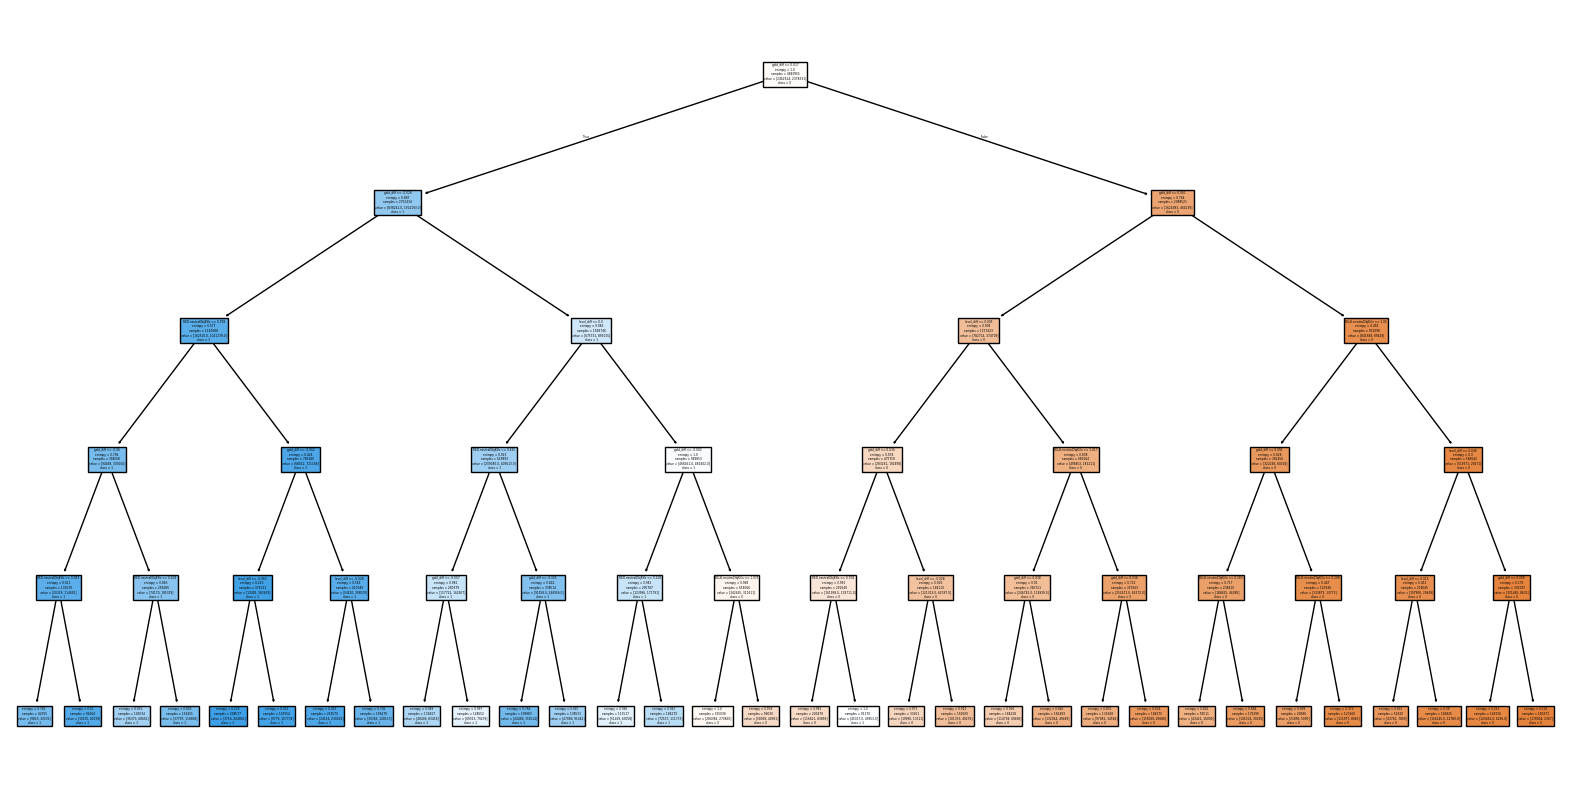

In [8]:
"""
Predict the entire test set
"""

# Predict the entire test set
y_pred = clf.predict(X_test)

# Show the tree structure
plt.figure(figsize=(20, 10))
plot_tree(clf, filled=True, feature_names=X.columns, class_names=["0", "1"])
plt.show()

### 3.2/ Model Evaluation

********** Decision Tree SCORES **********
Mean Absolute Error (MAE): 0.2625
Mean Squared Error (MSE): 0.2625
Root Mean Squared Error (RMSE): 0.5124
R^2 Score: -0.0505
f1 Score: 0.7216
Precision Score: 0.7524
Recall Score: 0.6931
Brier Score: 0.2625
********************************************
********** Decision Tree ACCURACY **********
Accuracy: 0.7375
********************************************


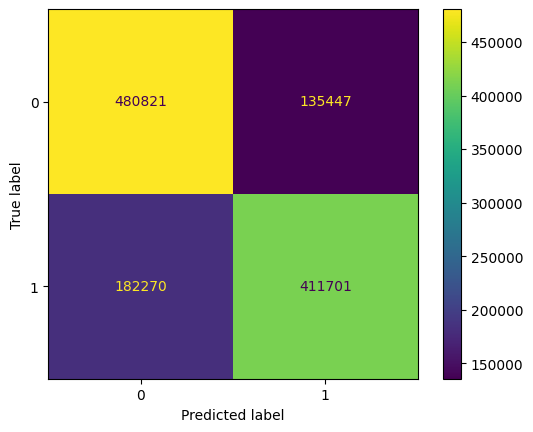

In [9]:
"""
Evaluate the model
Using :
- Mean Absolute Error
- Mean Squared Error
- Root Mean Squared Error
- R^2 Score
- F1 Score
- Precision Score
- Recall Score
"""

# Show statistics
# Evaluate the model using MAE, MSE, RMSE, R^2 Score, F1 score, Precision Score and Recall Score
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)
brier_score = brier_score_loss(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)


print("********** Decision Tree SCORES **********")
print(f"Mean Absolute Error (MAE): {mae:.4f}")
print(f"Mean Squared Error (MSE): {mse:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")
print(f"R^2 Score: {r2:.4f}")
print(f"f1 Score: {f1:.4f}")
print(f"Precision Score: {precision:.4f}")
print(f"Recall Score: {recall:.4f}")
print(f"Brier Score: {brier_score:.4f}")
print("********************************************")

# Get the final accuracy and the confusion matrix
accuracy = accuracy_score(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)

print("********** Decision Tree ACCURACY **********")
print(f"Accuracy: {accuracy:.4f}")
print("********************************************")

# Plot confusion matrix
cmatrix_display = ConfusionMatrixDisplay(confusion_matrix=conf_matrix, display_labels=["0", "1"])
cmatrix_display.plot() 

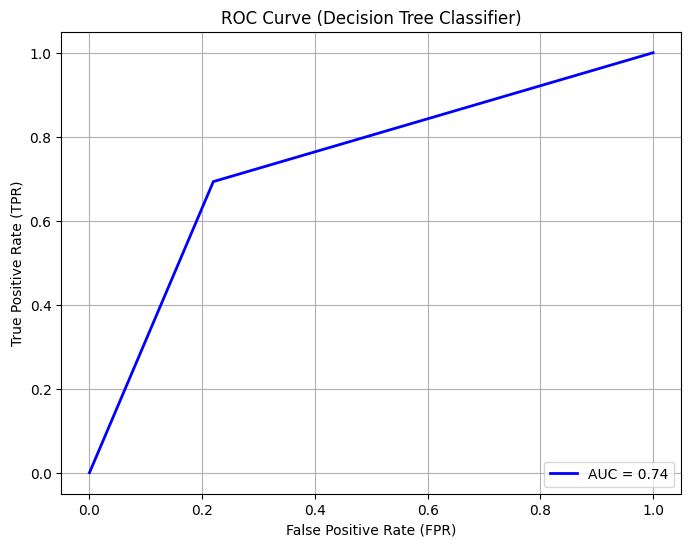

AUC-ROC Score: 0.7367


In [10]:
"""
ROC Curve & AUC-ROC Score
"""

# Compute ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_pred)

# Compute AUC-ROC score
auc_roc = roc_auc_score(y_test, y_pred)

# Plot ROC Curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='blue', lw=2, label=f'AUC = {auc_roc:.2f}')
plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR)')
plt.title('ROC Curve (Decision Tree Classifier)')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

# Print AUC-ROC score
print(f"AUC-ROC Score: {auc_roc:.4f}")

In [11]:
"""
Accuracy per timestamp group (5 groups)
"""

assert len(y_test_with_timestamp['timestamp']) == len(y_pred) == len(y_test)

# Store each row
y_pred_info_list = []

for i in range(len(y_test_with_timestamp)):
    timestamp = y_test_with_timestamp['timestamp'].iloc[i]
    selected_y_pred = y_pred[i]
    selected_y_true = y_test.iloc[i]
    y_pred_info_list.append({'timestamp': timestamp, 'y_pred': selected_y_pred, 'y_true': selected_y_true})

# Create a dataframe from the list
y_pred_info = pd.DataFrame(y_pred_info_list)

print(y_pred_info.head(5))

# Create timestamp groups using pd.cut
y_pred_info['timestamp_group'] = pd.cut(y_pred_info['timestamp'], bins=5)

# Store the mean accuracy (overall testing set) in "mean_accuracy"
mean_accuracy = accuracy

   timestamp  y_pred  y_true
0   0.390346       0       0
1   0.015618       0       0
2   0.000001       0       0
3   0.124945       0       0
4   0.374755       0       0


0.7374758208915759


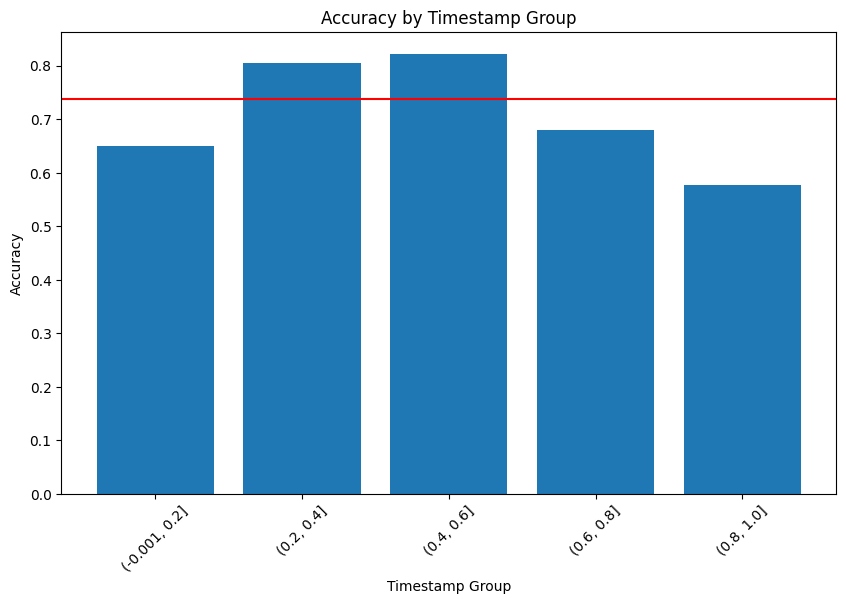

In [12]:
# Initialize an empty list to store accuracy per group
accuracy_per_group = []

# Iterate through each group and calculate accuracy
for group in y_pred_info['timestamp_group'].unique():
    subgroup = y_pred_info[y_pred_info['timestamp_group'] == group]
    # Calculate accuracy
    accuracy = accuracy_score(subgroup['y_true'], subgroup['y_pred'])
    # Append the accuracy to the list
    accuracy_per_group.append(accuracy)

accuracy_df = pd.DataFrame({
    'timestamp_group': y_pred_info['timestamp_group'].unique(),
    'accuracy': accuracy_per_group
})

# Sort the dataframe by timestamp group
accuracy_df = accuracy_df.sort_values(by='timestamp_group')

plt.figure(figsize=(10, 6))
plt.bar(accuracy_df['timestamp_group'].astype(str), accuracy_df['accuracy'])
print(mean_accuracy)
plt.axhline(y=mean_accuracy, color='r', label='Mean Accuracy')
plt.xlabel('Timestamp Group')
plt.ylabel('Accuracy')
plt.title('Accuracy by Timestamp Group')
plt.xticks(rotation=45)
plt.show()

# 4/ Fine Tuning the Model

In [13]:
"""
Hyperparameter tuning
Using GridSearchCV to find the best hyperparameters for the DecisionTreeClassifier
"""

# Define the hyperparameters grid
param_grid = {
    'max_depth': [3, 5, 10],
    'min_samples_split': [2, 5, 10],
    'criterion': ['gini', 'entropy']
}

# Initialize the GridSearchCV
grid_search = GridSearchCV(
    estimator=DecisionTreeClassifier(random_state=42),
    param_grid=param_grid,
    cv=5,
    verbose=2,
    n_jobs=-1,
    scoring='accuracy'
)

# Fit the model
grid_search.fit(X_train, y_train)

# Get the best hyperparameters
best_params = grid_search.best_params_
best_score = grid_search.best_score_

print("********** BEST HYPERPARAMETERS **********")
print(f"Best Hyperparameters: {best_params}")
print(f"Best Score: {best_score:.4f}")
print("******************************************")

Fitting 5 folds for each of 18 candidates, totalling 90 fits
[CV] END ...criterion=gini, max_depth=3, min_samples_split=2; total time=  10.8s
[CV] END ...criterion=gini, max_depth=3, min_samples_split=2; total time=  10.8s
[CV] END ...criterion=gini, max_depth=3, min_samples_split=2; total time=  10.9s
[CV] END ...criterion=gini, max_depth=3, min_samples_split=2; total time=  11.0s
[CV] END ...criterion=gini, max_depth=3, min_samples_split=5; total time=  11.0s
[CV] END ...criterion=gini, max_depth=3, min_samples_split=5; total time=  11.1s
[CV] END ...criterion=gini, max_depth=3, min_samples_split=5; total time=  11.1s
[CV] END ...criterion=gini, max_depth=3, min_samples_split=5; total time=  11.1s
[CV] END ...criterion=gini, max_depth=3, min_samples_split=5; total time=  11.1s
[CV] END ...criterion=gini, max_depth=3, min_samples_split=2; total time=  11.3s
[CV] END ..criterion=gini, max_depth=3, min_samples_split=10; total time=   8.0s
[CV] END ..criterion=gini, max_depth=3, min_samp

# 5/ Final Model using K-Fold Cross Validation and Hyperparameter Tuning

In [ ]:
"""
Retreive the best model and use a cross-validation to evaluate it
"""

# Get the best model
best_model = grid_search.best_estimator_

# Perform cross-validation
from sklearn.model_selection import cross_val_score

# Perform cross-validation
cv_scores = cross_val_score(best_model, X_train, y_train, cv=5, scoring='accuracy', verbose=2, n_jobs=-1)

# Print the cross-validation scores
print("*********************************************")
print(f"Cross-Validation Scores: {cv_scores}")
print(f"Mean CV Score: {cv_scores.mean():.4f}")
print("*********************************************")

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 10 concurrent workers.


[CV] END .................................................... total time=  19.6s
[CV] END .................................................... total time=  19.8s
[CV] END .................................................... total time=  19.7s
[CV] END .................................................... total time=  19.8s
[CV] END .................................................... total time=  20.1s
*********************************************
Cross-Validation Scores: [0.74149935 0.7424093  0.74225747 0.74262207 0.74188151]
Mean CV Score: 0.7421
*********************************************


[Parallel(n_jobs=-1)]: Done   5 out of   5 | elapsed:   21.0s finished


## 5.1/ Final ROC Curve & AUC-ROC Score

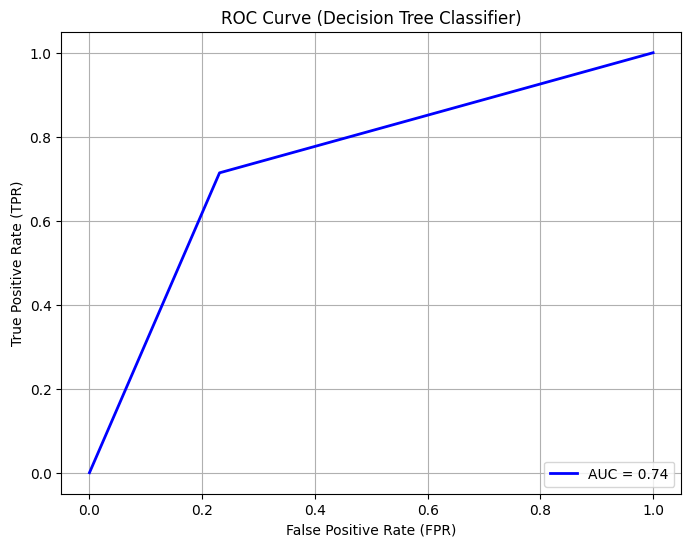

AUC-ROC Score: 0.7416


In [15]:
"""
ROC Curve & AUC-ROC Score of the best model
"""

# Predict the entire test set
y_pred = best_model.predict(X_test)

# Compute ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_pred)

# Compute AUC-ROC score
auc_roc = roc_auc_score(y_test, y_pred)

# Plot ROC Curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='blue', lw=2, label=f'AUC = {auc_roc:.2f}')
plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR)')
plt.title('ROC Curve (Decision Tree Classifier)')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

# Print AUC-ROC score
print(f"AUC-ROC Score: {auc_roc:.4f}")

In [18]:
"""
Accuracy per timestamp group (5 groups)
"""

assert len(y_test_with_timestamp['timestamp']) == len(y_pred) == len(y_test)

# Store each row
y_pred_info_list = []

for i in range(len(y_test_with_timestamp)):
    timestamp = y_test_with_timestamp['timestamp'].iloc[i]
    selected_y_pred = y_pred[i]
    selected_y_true = y_test.iloc[i]
    y_pred_info_list.append({'timestamp': timestamp, 'y_pred': selected_y_pred, 'y_true': selected_y_true})

# Create a dataframe from the list
y_pred_info = pd.DataFrame(y_pred_info_list)

print(y_pred_info.head(5))

# Create timestamp groups using pd.cut
y_pred_info['timestamp_group'] = pd.cut(y_pred_info['timestamp'], bins=5)

# Store the mean accuracy (overall testing set) in "mean_accuracy"
mean_accuracy = cv_scores.mean()

   timestamp  y_pred  y_true
0   0.390346       1       0
1   0.015618       0       0
2   0.000001       0       0
3   0.124945       0       0
4   0.374755       0       0


0.7421339384480954


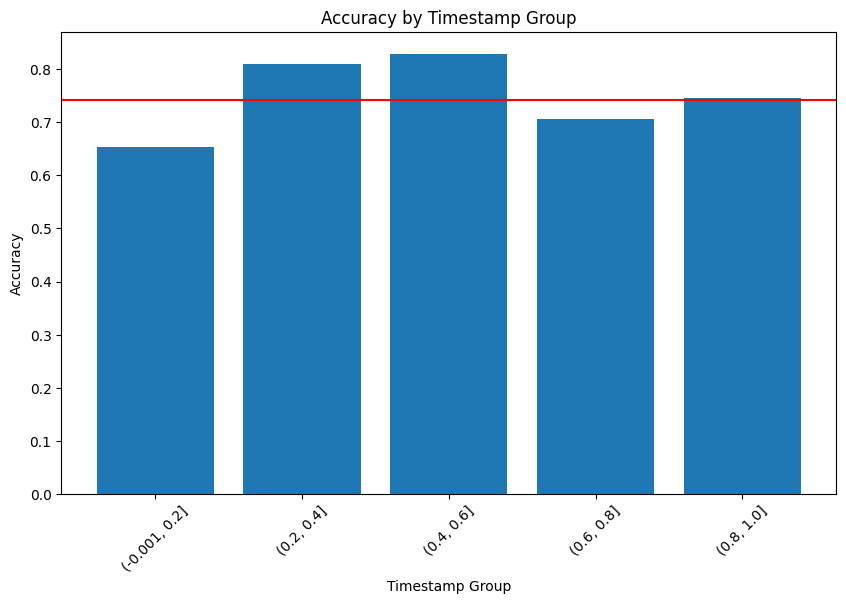

In [19]:
# Initialize an empty list to store accuracy per group
accuracy_per_group = []

# Iterate through each group and calculate accuracy
for group in y_pred_info['timestamp_group'].unique():
    subgroup = y_pred_info[y_pred_info['timestamp_group'] == group]
    # Calculate accuracy
    accuracy = accuracy_score(subgroup['y_true'], subgroup['y_pred'])
    # Append the accuracy to the list
    accuracy_per_group.append(accuracy)

accuracy_df = pd.DataFrame({
    'timestamp_group': y_pred_info['timestamp_group'].unique(),
    'accuracy': accuracy_per_group
})

# Sort the dataframe by timestamp group
accuracy_df = accuracy_df.sort_values(by='timestamp_group')

plt.figure(figsize=(10, 6))
plt.bar(accuracy_df['timestamp_group'].astype(str), accuracy_df['accuracy'])
print(mean_accuracy)
plt.axhline(y=mean_accuracy, color='r', label='Mean Accuracy')
plt.xlabel('Timestamp Group')
plt.ylabel('Accuracy')
plt.title('Accuracy by Timestamp Group')
plt.xticks(rotation=45)
plt.show()